<a href="https://colab.research.google.com/github/reitezuz/18NES1-2026/blob/main/week06/hw/example_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework of a student
- a simple task, comparing a model without hidden layer and with hidden layers
- Observation: accuracy is not bad for both models, but the visualisations show, that the model without hidden layers doesn't work at all.

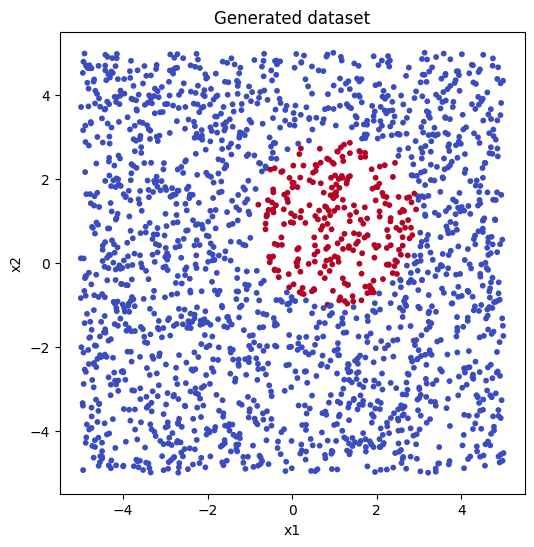

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7883 - loss: 0.5302 - val_accuracy: 0.8625 - val_loss: 0.4820
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8719 - loss: 0.4321 - val_accuracy: 0.8625 - val_loss: 0.4188
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.3816 - val_accuracy: 0.8625 - val_loss: 0.3817
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.3503 - val_accuracy: 0.8625 - val_loss: 0.3557
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.3281 - val_accuracy: 0.8625 - val_loss: 0.3358
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.3112 - val_accuracy: 0.8625 - val_loss: 0.3197
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.2979 - val_accuracy: 0.8625 - val_loss: 0.3068
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.2871 - val_accuracy: 0.8625 - val_loss:

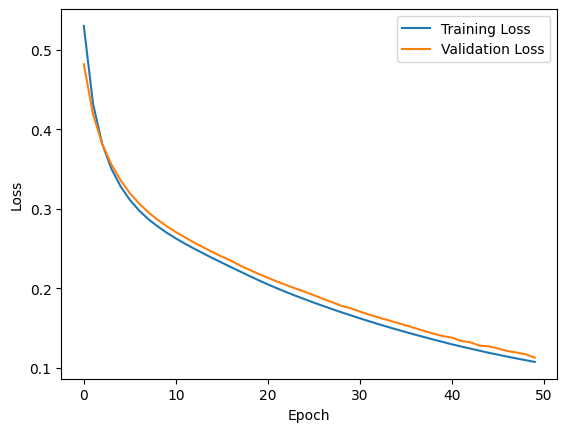

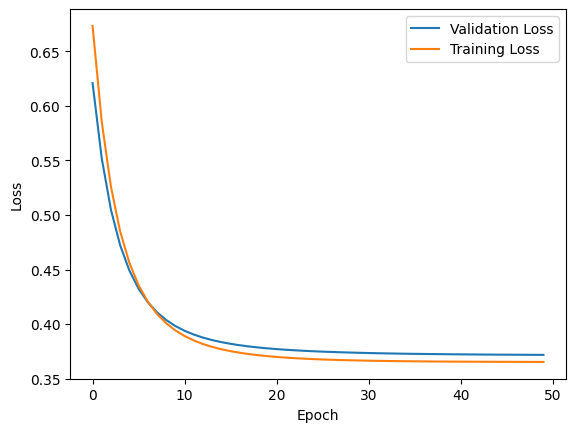

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9600 - loss: 0.1104  
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9734 - loss: 0.1059 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9563 - loss: 0.1127 
Train Accuracy: 0.9734 | Train Loss: 0.1059
Validation Accuracy: 0.9563 | Validation Loss: 0.1127
Test Accuracy: 0.9600 | Test Loss: 0.1104
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8800 - loss: 0.3529  
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8719 - loss: 0.3653 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8625 - loss: 0.3718 
Train Accuracy: 0.8719 | Train Loss: 0.3653
Validation Accuracy: 0.8625 | Validation Loss: 0.3718
Test Accuracy: 0.8800 | Test Loss: 0.3529
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[[0 0 0 0 0 0 1 1 0 0]]
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[[0 0 0 0 0 0 0 0 0 0]]


In [7]:
import numpy as np
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

##########################################################################
# 1. Load, observe and analyze the data:

def generate_dataset(n_samples=1000, noise=0.01, random_state=42):

    rng = np.random.RandomState(random_state)

    # generate random points
    X = rng.uniform(-5, 5, size=(n_samples, 2))
    y = np.zeros(n_samples)

    for i, (x1, x2) in enumerate(X):

        # ----- rectangle -----
        # if -3 < x1 < 3 and -3 < x2 < -1:
        #     y[i] = 1

        # ----- CIRCLE
        cx, cy = 1, 1
        a, b = 2, 2

        if ((x1 - cx)**2)/a**2 + ((x2 - cy)**2)/b**2 < 1:
            y[i] = 1

        # # ----- spiral -----
        # r = np.sqrt(x1**2 + x2**2)
        # theta = np.arctan2(x2, x1)

        # if abs(r - theta) < 0.5:
        #     y[i] = 1

    # add noise
    # X += noise * rng.randn(*X.shape)

    return X, y.astype(int)
import matplotlib.pyplot as plt

def plot_dataset(X, y):

    plt.figure(figsize=(6,6))
    plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=10)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Generated dataset")
    plt.show()

X, y = generate_dataset(2000)

plot_dataset(X, y)
##########################################################################
# 2. Preprocess and clean the data:
# Split the dataset into training, validation and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Standardize the features to improve training stability
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

##########################################################################
# 3. Define the MLP model using Keras
# 3a.  Define the model architecture (type of the model, number of layers, activation functions)
model = keras.Sequential([
    layers.InputLayer(shape=(X_train.shape[1],)),  # Input Layer
    layers.Dense(30, activation='relu'),  # First hidden layer
    layers.Dense(15, activation='relu'),  # Second hidden layer
    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])
model2 = keras.Sequential([
    layers.InputLayer(shape=(X_train.shape[1],)),  # Input Layer
    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

#3b. Set model hyperparameters (Appropriate loss function, optimizer and its parameters, evaluation metrics)
#model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
model2.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
##########################################################################
# 4. Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_val, y_val))
history2 = model2.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_val, y_val))

# Plot history:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.plot(history2.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

##########################################################################
# 5. Evaluate the model and make predictions
# 5a. Evaluate the model on the train, validation and test sets
test_loss, test_acc = model.evaluate(X_test, y_test)
train_loss, train_acc = model.evaluate(X_train, y_train)
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} | Validation Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

test_loss, test_acc = model2.evaluate(X_test, y_test)
train_loss, train_acc = model2.evaluate(X_train, y_train)
val_loss, val_acc = model2.evaluate(X_val, y_val)
print(f"Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} | Validation Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")
# 5b. Make predictions
predictions = (model.predict(X_test) > 0.5).astype(int)
print(predictions[:10].T)

predictions2 = (model2.predict(X_test) > 0.5).astype(int)
print(predictions2[:10].T)


# Verdict (Student comment)
We started with non-linear data (a circle) and executed a one-layer network with a single hidden layer and compared it with a multi-layer network with 3 hidden layers. The multi-layer network performed better as seen in theory classes due to its ability to learn non-linear relationships. However, the  loss was not too different between the two models as I personally expected

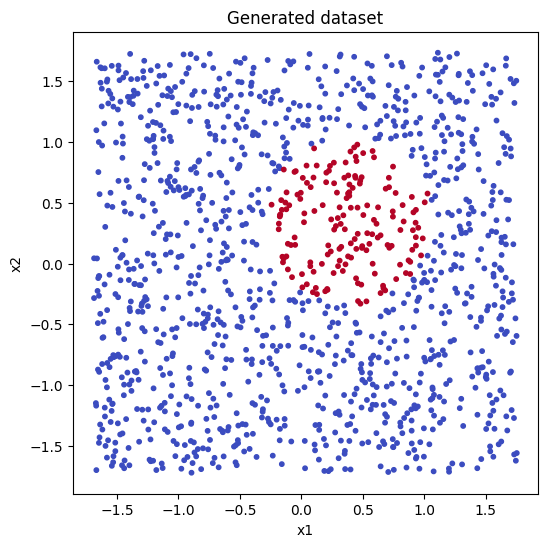

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


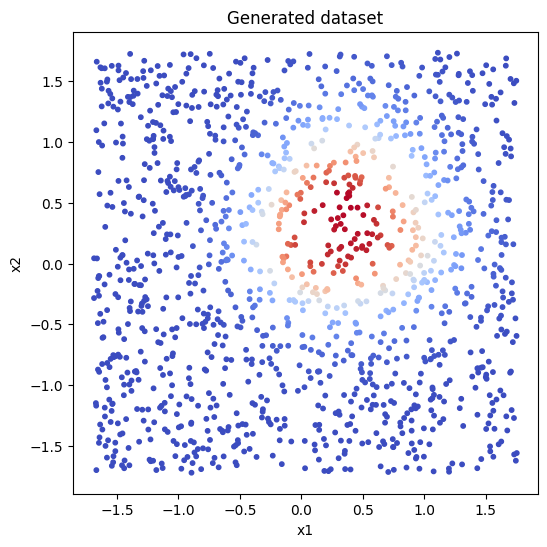

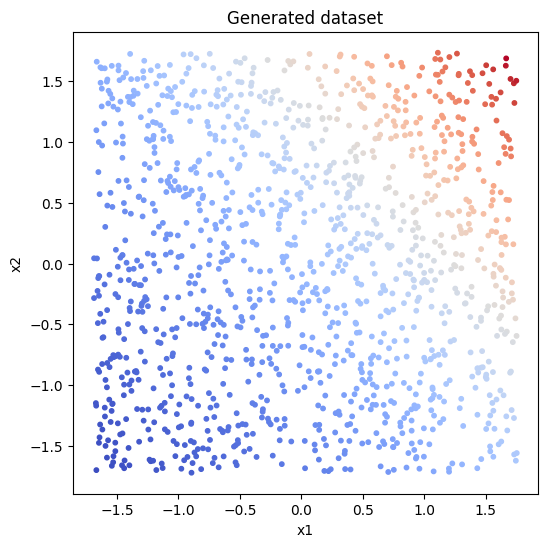

In [8]:

plot_dataset(X_train, y_train)


predictions = model.predict(X_train)
predictions2 =model2.predict(X_train)
plot_dataset(X_train, predictions)
plot_dataset(X_train, predictions2)

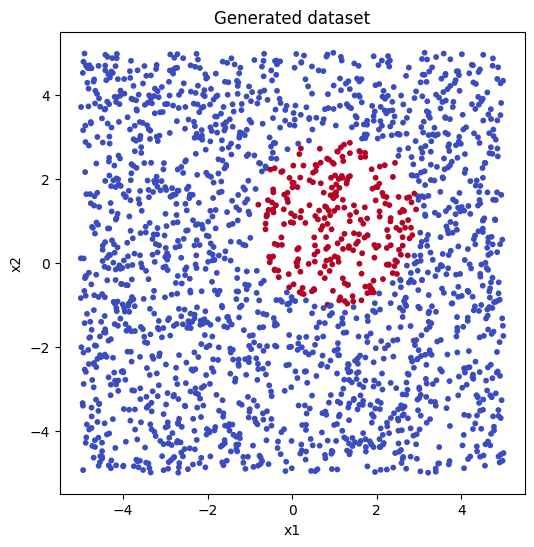

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7336 - loss: 0.6214 - val_accuracy: 0.8625 - val_loss: 0.5278
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8719 - loss: 0.4728 - val_accuracy: 0.8625 - val_loss: 0.4286
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8719 - loss: 0.3980 - val_accuracy: 0.8625 - val_loss: 0.3770
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8719 - loss: 0.3569 - val_accuracy: 0.8625 - val_loss: 0.3487
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.3338 - val_accuracy: 0.8625 - val_loss: 0.3326
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.3199 - val_accuracy: 0.8625 - val_loss: 0.3224
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.3105 - val_accuracy: 0.8625 - val_loss: 0.3149
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8719 - loss: 0.3035 - val_accuracy: 0.8625 - v

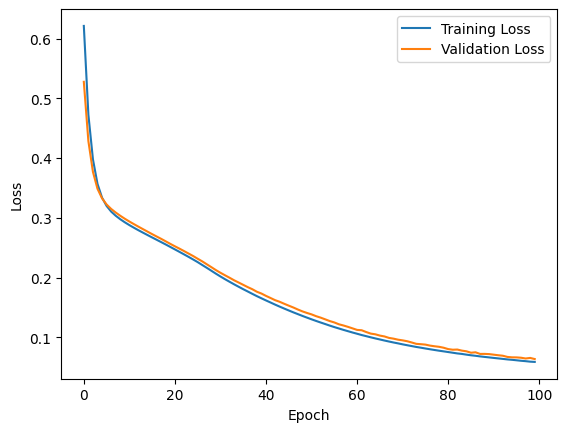

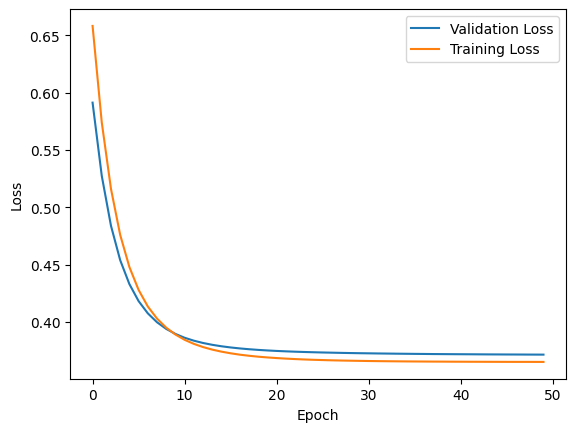

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9775 - loss: 0.0641  
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9930 - loss: 0.0578 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9906 - loss: 0.0635 
Train Accuracy: 0.9930 | Train Loss: 0.0578
Validation Accuracy: 0.9906 | Validation Loss: 0.0635
Test Accuracy: 0.9775 | Test Loss: 0.0641
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8800 - loss: 0.3529  
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8719 - loss: 0.3652 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8625 - loss: 0.3716 
Train Accuracy: 0.8719 | Train Loss: 0.3652
Validation Accuracy: 0.8625 | Validation Loss: 0.3716
Test Accuracy: 0.8800 | Test Loss: 0.3529
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[[0 0 0 1 0 0 1 1 0 0]]
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[[0 0 0 0 0 0 0 0 0 0]]


In [9]:
import numpy as np
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

##########################################################################
# 1. Load, observe and analyze the data:

def generate_dataset(n_samples=1000, noise=0.01, random_state=42):

    rng = np.random.RandomState(random_state)

    # generate random points
    X = rng.uniform(-5, 5, size=(n_samples, 2))
    y = np.zeros(n_samples)

    for i, (x1, x2) in enumerate(X):

        # ----- rectangle -----
        # if -3 < x1 < 3 and -3 < x2 < -1:
        #     y[i] = 1

        # ----- CIRCLE
        cx, cy = 1, 1
        a, b = 2, 2

        if ((x1 - cx)**2)/a**2 + ((x2 - cy)**2)/b**2 < 1:
            y[i] = 1

        # # ----- spiral -----
        # r = np.sqrt(x1**2 + x2**2)
        # theta = np.arctan2(x2, x1)

        # if abs(r - theta) < 0.5:
        #     y[i] = 1

    # add noise
    # X += noise * rng.randn(*X.shape)

    return X, y.astype(int)
import matplotlib.pyplot as plt

def plot_dataset(X, y):

    plt.figure(figsize=(6,6))
    plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=10)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Generated dataset")
    plt.show()

X, y = generate_dataset(2000)

plot_dataset(X, y)
##########################################################################
# 2. Preprocess and clean the data:
# Split the dataset into training, validation and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Standardize the features to improve training stability
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

##########################################################################
# 3. Define the MLP model using Keras
# 3a.  Define the model architecture (type of the model, number of layers, activation functions)
model = keras.Sequential([
    layers.InputLayer(shape=(X_train.shape[1],)),  # Input Layer
    layers.Dense(30, activation='relu'),  # First hidden layer
    layers.Dense(15, activation='relu'),  # Second hidden layer
    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])
model2 = keras.Sequential([
    layers.InputLayer(shape=(X_train.shape[1],)),  # Input Layer
    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

#3b. Set model hyperparameters (Appropriate loss function, optimizer and its parameters, evaluation metrics)
#model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
model2.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
##########################################################################
# 4. Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val))
history2 = model2.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_val, y_val))

# Plot history:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.plot(history2.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

##########################################################################
# 5. Evaluate the model and make predictions
# 5a. Evaluate the model on the train, validation and test sets
test_loss, test_acc = model.evaluate(X_test, y_test)
train_loss, train_acc = model.evaluate(X_train, y_train)
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} | Validation Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

test_loss, test_acc = model2.evaluate(X_test, y_test)
train_loss, train_acc = model2.evaluate(X_train, y_train)
val_loss, val_acc = model2.evaluate(X_val, y_val)
print(f"Train Accuracy: {train_acc:.4f} | Train Loss: {train_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} | Validation Loss: {val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")
# 5b. Make predictions
predictions = (model.predict(X_test) > 0.5).astype(int)
print(predictions[:10].T)

predictions2 = (model2.predict(X_test) > 0.5).astype(int)
print(predictions2[:10].T)


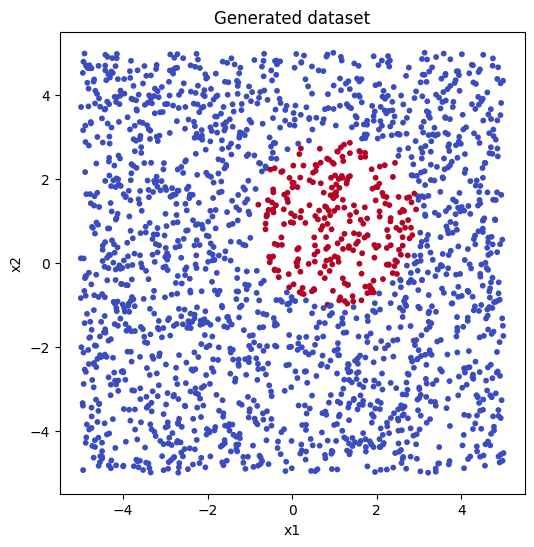

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step


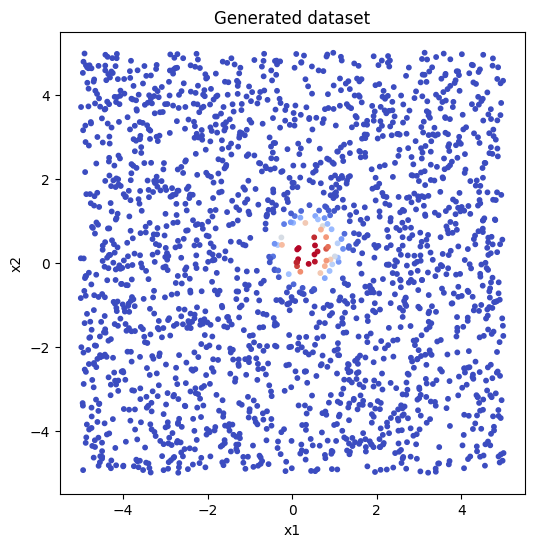

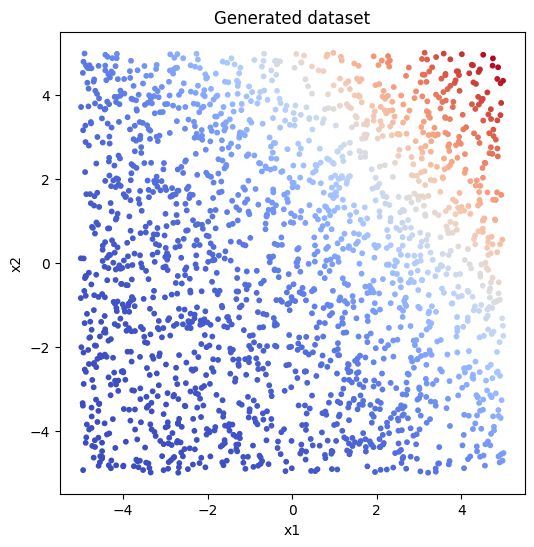

In [10]:
plot_dataset(X, y)

predictions_all = model.predict(X)
predictions_all2 =model2.predict(X)
plot_dataset(X, predictions_all)
plot_dataset(X, predictions_all2)